# Imputación de Datos Faltantes
## Dataset: Ames Housing — Precios de Casas en Iowa, EE.UU.

**Fuente:** [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)  
**Carga directa (sin cuenta Kaggle):** vía `sklearn` / `openml`

**Tarea de minería de datos:** Predecir el precio de venta de una casa (`SalePrice`) → **Regresión**

---

### La historia que hace único a este dataset

En Ames Housing, un dato faltante **casi nunca es un error**. La mayoría de las veces significa que  
**la casa simplemente no tiene esa característica.**

| Variable | % Faltante | Lo que realmente significa |
|---|---|---|
| `PoolQC` | 99.5% | La casa **no tiene piscina** |
| `Alley` | 93.8% | La casa **no tiene callejón lateral** |
| `Fence` | 80.2% | La casa **no tiene cerca** |
| `FireplaceQu` | 47.3% | La casa **no tiene chimenea** |
| `GarageType` | 5.5% | La casa **no tiene garaje** |
| `LotFrontage` | 17.7% | **Dato genuinamente faltante** (depende del vecindario) |
| `Electrical` | 0.07% | **Error de captura** (1 solo registro) |

> **Lección central:** Aplicar media o moda indiscriminadamente a estas variables sería  
> uno de los errores más graves que puede cometer un analista de datos.  
> La descripción del dato manda sobre cualquier algoritmo.

### Técnicas que exploraremos
1. No hacer nada
2. Dejar que el algoritmo maneje los faltantes
3. Constante con significado semántico (MNAR estructural)
4. Media / Mediana (numérica)
5. Moda (categórica)
6. Imputación por grupo con conocimiento del dominio
7. K-NN
8. Naive Bayes (categórica)
9. MICE
10. Deep Learning (MLP)
11. Comparación y criterios de elección


---
## 0. Librerías

In [1]:
# !pip install missingno scikit-learn pandas numpy matplotlib seaborn
print('Continúa con la siguiente celda si ya están instaladas.')

Continúa con la siguiente celda si ya están instaladas.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
print('✓ Librerías importadas.')

✓ Librerías importadas.


---
## 1. Carga del dataset

Usamos `fetch_openml` de sklearn para cargar el dataset sin necesidad de cuenta en Kaggle.


In [3]:
# Cargar Ames Housing desde OpenML (no requiere cuenta Kaggle)
print('Cargando dataset desde OpenML...')
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df_raw = ames.frame.copy()

print(f'Dataset cargado: {df_raw.shape[0]} casas × {df_raw.shape[1]} columnas')
print(f'Tipos: {df_raw.dtypes.value_counts().to_dict()}')

Cargando dataset desde OpenML...
Dataset cargado: 1460 casas × 81 columnas
Tipos: {dtype('O'): 43, dtype('int64'): 35, dtype('float64'): 3}


In [4]:
# Vista inicial
df_raw.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## 1.5 Conceptos clave: MCAR, MAR y MNAR

Antes de analizar los faltantes del dataset, necesitamos entender **por qué falta un dato**,  
porque eso determina completamente qué técnica de imputación es válida.

Rubin (1976) propuso la clasificación canónica de los mecanismos de datos faltantes en tres tipos:


### MCAR — *Missing Completely At Random* (Faltante Completamente al Azar)

**Definición:** La probabilidad de que un dato falte **no depende de ninguna variable**,  
ni del valor faltante en sí ni de otras variables observadas.  
El dato desaparece de forma completamente aleatoria, como si alguien lanzara una moneda.

**Analogía:** Una encuesta en papel donde el viento se llevó algunas hojas al azar.  
No importa quién respondió, qué respondió ni cuándo: simplemente se perdió por accidente.

**Ejemplo en Ames Housing:**  
`Electrical` — solo 1 registro faltante de 1,460. No hay ningún patrón identificable.  
El dato simplemente no se registró ese día por error.

**Consecuencia para la imputación:**  
- Es el caso más benigno: cualquier método funciona sin introducir sesgo significativo
- Con porcentaje bajo (<5%): media, mediana o moda son suficientes
- El análisis estadístico sobre los datos restantes sigue siendo representativo

```
P(falta | X_obs, X_miss) = P(falta)
→ La probabilidad de faltar es constante, independiente de todo
```


### MAR — *Missing At Random* (Faltante Al Azar Condicional)

**Definición:** La probabilidad de que un dato falte depende de **otras variables observadas**,  
pero NO del valor del dato faltante en sí.  
Una vez que controlas las variables observadas, el faltante es aleatorio.

**Analogía:** En una encuesta de salud, los hombres responden menos la pregunta sobre peso  
que las mujeres. El faltante depende del sexo (observable), no del peso real (inobservable).  
Si sabes el sexo del encuestado, puedes modelar mejor el faltante.

**Ejemplo en Ames Housing:**  
`LotFrontage` (frente del lote) — el 17.7% está faltante, pero ese porcentaje **varía por vecindario**:  
algunos vecindarios tienen más faltantes que otros. El faltante depende de `Neighborhood` (observable).  
Una vez controlado el vecindario, el faltante es aleatorio dentro de ese grupo.

**Consecuencia para la imputación:**  
- Se puede imputar usando las otras variables observadas que predicen el faltante
- Métodos recomendados: **KNN, MICE, regresión, imputación por grupo**
- La imputación produce estimaciones no sesgadas si se incluyen las variables relevantes

```
P(falta | X_obs, X_miss) = P(falta | X_obs)
→ La probabilidad de faltar depende solo de lo que SÍ observamos
```


### MNAR — *Missing Not At Random* (Faltante No Al Azar)

**Definición:** La probabilidad de que un dato falte depende del **propio valor faltante**,  
incluso después de controlar todas las demás variables observadas.  
Hay una razón sistemática para que ese valor específico falte.

**Analogía:** En una encuesta salarial, las personas con salarios muy altos o muy bajos  
tienden a no responder esa pregunta. El faltante depende precisamente del valor del salario  
(lo que no podemos observar). No importa cuántas otras variables controles: el patrón persiste.

**Existen dos subtipos importantes:**

| Subtipo | Descripción | Ejemplo en Ames |
|---|---|---|
| **MNAR Estructural** | El dato falta porque la característica **no existe** en ese registro | `PoolQC = NaN` → la casa no tiene piscina |
| **MNAR Informativo** | El dato falta por razones relacionadas con su propio valor | Precios muy altos no reportados |

**Ejemplo en Ames Housing:**  
`PoolQC` (calidad de la piscina) — el 99.5% falta porque las casas simplemente no tienen piscina.  
El faltante depende del valor mismo: si la piscina no existe, no hay calidad que registrar.  
Lo mismo aplica a `FireplaceQu`, `GarageType`, `Alley`, `Fence`, `MiscFeature`.

**Consecuencia para la imputación:**  
- Es el caso más delicado: imputar con media o moda introduce sesgos graves
- Para **MNAR Estructural**: usar una **constante semántica** (`'Sin_piscina'`, `'Sin_garaje'`)
- Para **MNAR Informativo**: requiere modelos de selección o análisis de sensibilidad
- Siempre agregar una columna indicadora: `variable_era_faltante = 1/0`

```
P(falta | X_obs, X_miss) ≠ P(falta | X_obs)
→ La probabilidad de faltar depende del propio valor no observado
```


### Resumen comparativo

| Característica | MCAR | MAR | MNAR |
|---|---|---|---|
| **¿De qué depende el faltante?** | De nada | De otras variables observadas | Del propio valor faltante |
| **Sesgo si se ignora** | Ninguno (si % es bajo) | Bajo (si se modela bien) | Alto siempre |
| **Técnicas recomendadas** | Media, moda | KNN, MICE, grupo | Constante semántica, modelos especiales |
| **Frecuencia en la práctica** | Poco común | Común | Muy común |
| **Ejemplo en Ames** | `Electrical` (1 registro) | `LotFrontage` (por vecindario) | `PoolQC`, `GarageType`, `FireplaceQu` |

> **Regla práctica:**  
> Antes de imputar cualquier variable, pregúntate: *¿Por qué falta este dato?*  
> Si la respuesta es *"porque esa característica no existe"* → MNAR estructural → constante semántica.  
> Si la respuesta es *"depende de otras variables"* → MAR → KNN, MICE o grupo.  
> Si la respuesta es *"no hay patrón identificable"* → MCAR → cualquier método simple.


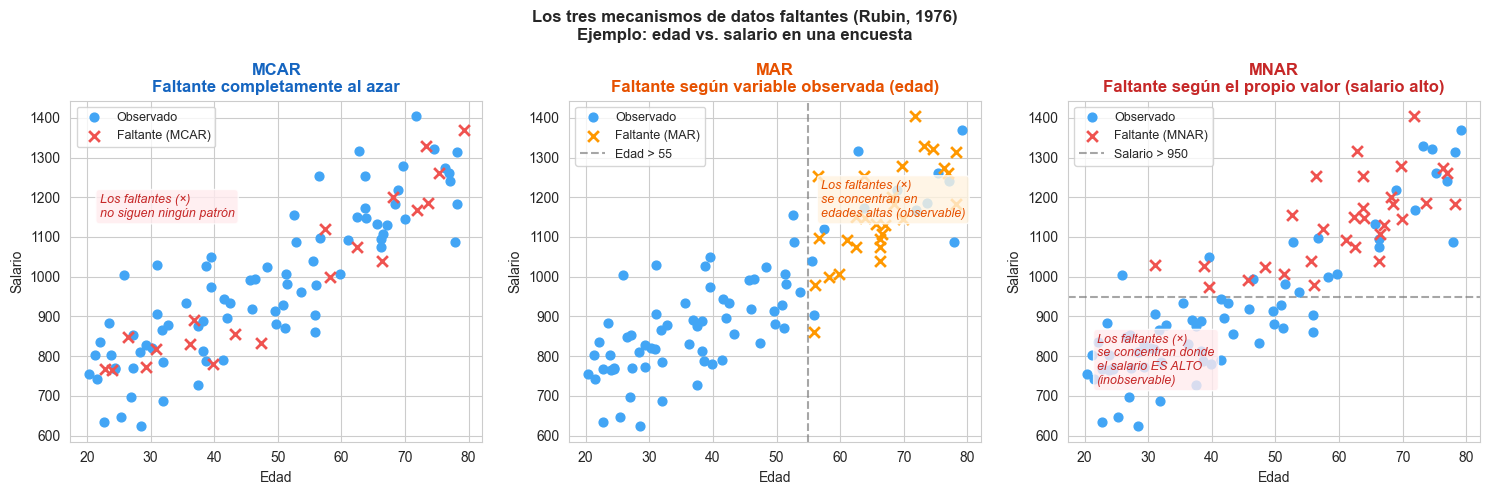

Observa:
  MCAR → los × están dispersos sin patrón
  MAR  → los × se concentran en edades altas (podemos modelarlo con edad)
  MNAR → los × se concentran en salarios altos (¡no podemos modelarlo si no sabemos el salario!)


In [5]:
# ── Visualización del concepto: los tres mecanismos de faltantes ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

np.random.seed(42)
n = 100
x = np.random.uniform(20, 80, n)   # edad
y = 500 + 10 * x + np.random.normal(0, 100, n)  # salario

# ── MCAR: falta completamente al azar ──
mask_mcar = np.random.rand(n) < 0.25
axes[0].scatter(x[~mask_mcar], y[~mask_mcar], c='#42A5F5', s=40, label='Observado', zorder=3)
axes[0].scatter(x[mask_mcar],  y[mask_mcar],  c='#EF5350', s=60, marker='x', linewidths=2,
                label='Faltante (MCAR)', zorder=3)
axes[0].set_title('MCAR\nFaltante completamente al azar', fontweight='bold', color='#1565C0')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Salario')
axes[0].legend(fontsize=9)
axes[0].text(22, 1150, 'Los faltantes (×)\nno siguen ningún patrón',
             fontsize=9, color='#C62828', style='italic',
             bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))

# ── MAR: falta según otra variable (edad > 50) ──
mask_mar = (x > 55) & (np.random.rand(n) < 0.7)  # más faltante en edades altas
axes[1].scatter(x[~mask_mar], y[~mask_mar], c='#42A5F5', s=40, label='Observado', zorder=3)
axes[1].scatter(x[mask_mar],  y[mask_mar],  c='#FF9800', s=60, marker='x', linewidths=2,
                label='Faltante (MAR)', zorder=3)
axes[1].axvline(55, color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Edad > 55')
axes[1].set_title('MAR\nFaltante según variable observada (edad)', fontweight='bold', color='#E65100')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Salario')
axes[1].legend(fontsize=9)
axes[1].text(57, 1150, 'Los faltantes (×)\nse concentran en\nedades altas (observable)',
             fontsize=9, color='#E65100', style='italic',
             bbox=dict(boxstyle='round', facecolor='#FFF3E0', alpha=0.8))

# ── MNAR: falta según el propio valor (salarios altos) ──
mask_mnar = (y > 950) & (np.random.rand(n) < 0.75)  # más faltante en salarios altos
axes[2].scatter(x[~mask_mnar], y[~mask_mnar], c='#42A5F5', s=40, label='Observado', zorder=3)
axes[2].scatter(x[mask_mnar],  y[mask_mnar],  c='#EF5350', s=60, marker='x', linewidths=2,
                label='Faltante (MNAR)', zorder=3)
axes[2].axhline(950, color='gray', linewidth=1.5, linestyle='--', alpha=0.7, label='Salario > 950')
axes[2].set_title('MNAR\nFaltante según el propio valor (salario alto)', fontweight='bold', color='#C62828')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Salario')
axes[2].legend(fontsize=9)
axes[2].text(22, 730, 'Los faltantes (×)\nse concentran donde\nel salario ES ALTO\n(inobservable)',
             fontsize=9, color='#C62828', style='italic',
             bbox=dict(boxstyle='round', facecolor='#FFEBEE', alpha=0.8))

plt.suptitle('Los tres mecanismos de datos faltantes (Rubin, 1976)\nEjemplo: edad vs. salario en una encuesta',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observa:')
print('  MCAR → los × están dispersos sin patrón')
print('  MAR  → los × se concentran en edades altas (podemos modelarlo con edad)')
print('  MNAR → los × se concentran en salarios altos (¡no podemos modelarlo si no sabemos el salario!)')

---
## 2. Diagnóstico de datos faltantes

El primer paso es entender **cuánto**, **dónde** y **por qué** falta.


In [6]:
# ── Tabla de faltantes: cantidad y porcentaje ──
faltantes = pd.DataFrame({
    'Faltantes': df_raw.isnull().sum(),
    'Porcentaje (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).query('Faltantes > 0').sort_values('Porcentaje (%)', ascending=False)

print(f'Variables con datos faltantes: {len(faltantes)} de {df_raw.shape[1]}')
print()
print(faltantes.to_string())

Variables con datos faltantes: 19 de 81

              Faltantes  Porcentaje (%)
PoolQC             1453           99.50
MiscFeature        1406           96.30
Alley              1369           93.80
Fence              1179           80.80
FireplaceQu         690           47.30
LotFrontage         259           17.70
GarageCond           81            5.50
GarageType           81            5.50
GarageYrBlt          81            5.50
GarageFinish         81            5.50
GarageQual           81            5.50
BsmtFinType2         38            2.60
BsmtExposure         38            2.60
BsmtCond             37            2.50
BsmtQual             37            2.50
BsmtFinType1         37            2.50
MasVnrType            8            0.50
MasVnrArea            8            0.50
Electrical            1            0.10


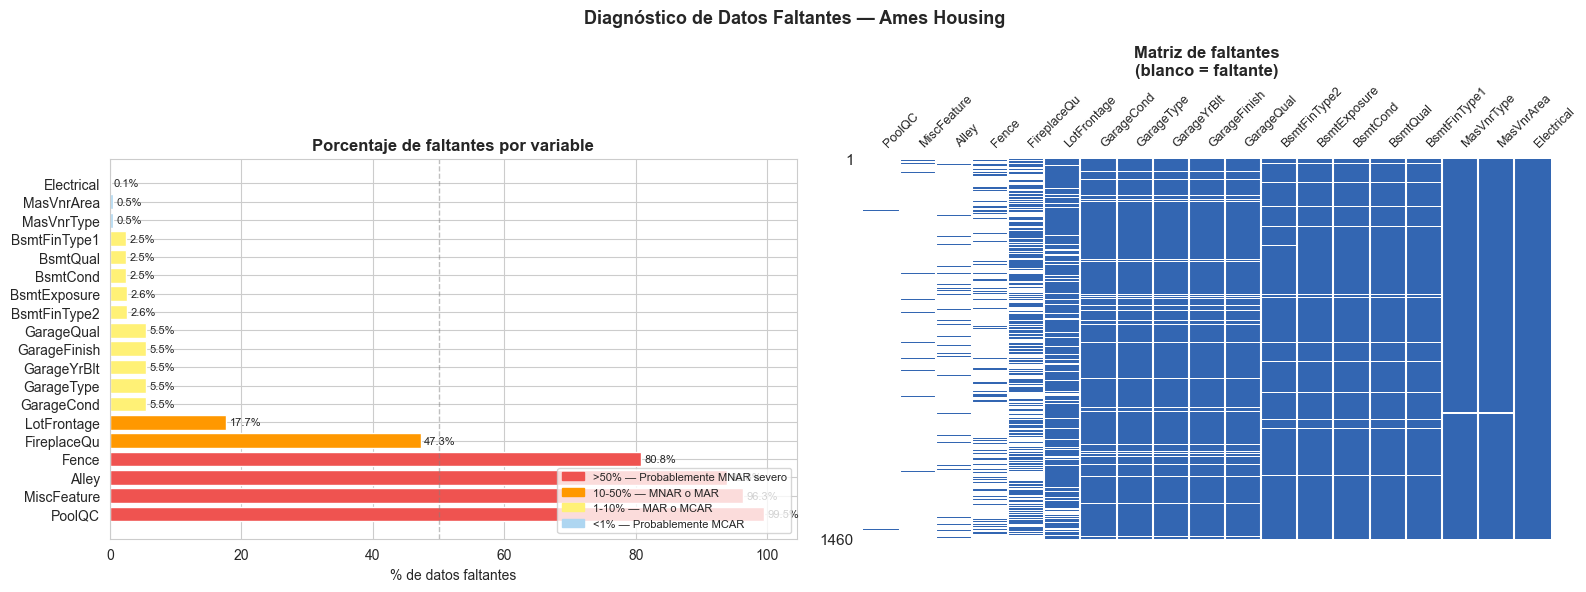

In [7]:
# ── Visualización 1: Gráfico de barras de faltantes ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras por porcentaje
colores = ['#EF5350' if p > 50 else '#FF9800' if p > 10 else '#FFF176' if p > 1 else '#AED6F1'
           for p in faltantes['Porcentaje (%)']]
axes[0].barh(faltantes.index, faltantes['Porcentaje (%)'], color=colores, edgecolor='white')
axes[0].set_xlabel('% de datos faltantes')
axes[0].set_title('Porcentaje de faltantes por variable', fontweight='bold')
axes[0].axvline(50, color='gray', linewidth=1, linestyle='--', alpha=0.5)

for i, (idx, row) in enumerate(faltantes.iterrows()):
    axes[0].text(row['Porcentaje (%)']+0.5, i, f'{row["Porcentaje (%)"]:.1f}%', va='center', fontsize=8)

# Leyenda de colores
leyenda = [
    mpatches.Patch(color='#EF5350', label='>50% — Probablemente MNAR severo'),
    mpatches.Patch(color='#FF9800', label='10-50% — MNAR o MAR'),
    mpatches.Patch(color='#FFF176', label='1-10% — MAR o MCAR'),
    mpatches.Patch(color='#AED6F1', label='<1% — Probablemente MCAR'),
]
axes[0].legend(handles=leyenda, loc='lower right', fontsize=8)

# Matriz de faltantes
msno.matrix(df_raw[faltantes.index.tolist()], ax=axes[1], sparkline=False,
            fontsize=9, color=(0.2, 0.4, 0.7))
axes[1].set_title('Matriz de faltantes\n(blanco = faltante)', fontweight='bold')

plt.suptitle('Diagnóstico de Datos Faltantes — Ames Housing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

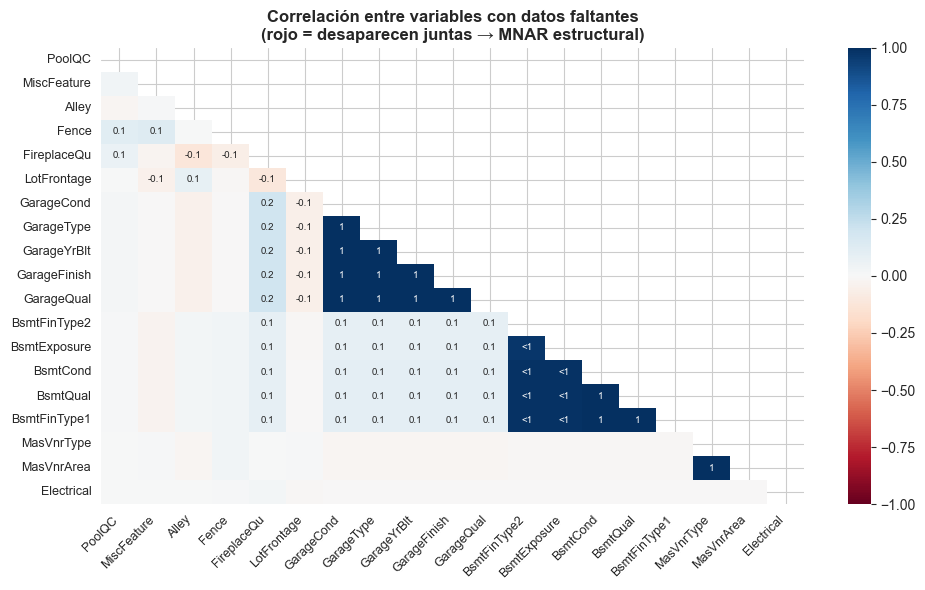

Observación: Garage* y Bsmt* aparecen muy correlacionadas entre sí.
Cuando falta GarageType, también faltan GarageFinish, GarageQual, GarageCond...
Esto confirma que el faltante es estructural: la casa no tiene garaje.


In [8]:
# ── Visualización 2: Mapa de calor de co-ocurrencia de faltantes ──
fig, ax = plt.subplots(figsize=(10, 6))
msno.heatmap(df_raw[faltantes.index.tolist()], ax=ax, fontsize=9)
ax.set_title('Correlación entre variables con datos faltantes\n(rojo = desaparecen juntas → MNAR estructural)', fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: Garage* y Bsmt* aparecen muy correlacionadas entre sí.')
print('Cuando falta GarageType, también faltan GarageFinish, GarageQual, GarageCond...')
print('Esto confirma que el faltante es estructural: la casa no tiene garaje.')

---
### 2.1 Clasificación de los faltantes: MNAR / MAR / MCAR

Para clasificar correctamente, consultamos la **descripción del dataset** (data_description.txt de Kaggle).

#### Grupo A — MNAR Estructural: *la casa no tiene esa característica*
```
PoolQC      → 'NA: No Pool' (99.5% missing)
Alley       → 'NA: No alley access' (93.8%)
Fence       → 'NA: No Fence' (80.2%)
MiscFeature → 'NA: None' (96.3%)
FireplaceQu → 'NA: No Fireplace' (47.3%)
GarageType  → 'NA: No Garage' (5.5%)
GarageFinish, GarageQual, GarageCond → ídem
BsmtQual, BsmtCond, BsmtExposure     → 'NA: No Basement'
MasVnrType  → 'NA: None' (0.5%)
```

#### Grupo B — MAR: *el faltante depende de otras variables observadas*
```
LotFrontage → Linear feet of street connected to property (17.7% missing)
              Su valor depende del vecindario (Neighborhood) y el tamaño del lote
GarageYrBlt → Año de construcción del garaje — falta cuando no hay garaje
MasVnrArea  → Área de la chapa — 0 si no hay chapa (correlacionado con MasVnrType)
```

#### Grupo C — MCAR: *error de captura, al azar*
```
Electrical → 1 solo registro faltante (0.07%) → no hay patrón
```

> **¿Por qué esto importa?** El tipo de faltante define la estrategia:  
> - MNAR estructural → **constante con significado** (no imputar un valor estadístico)  
> - MAR → **KNN, MICE, grupo** (aprovechar otras variables)  
> - MCAR → **media, mediana o moda** (cualquier método simple funciona)


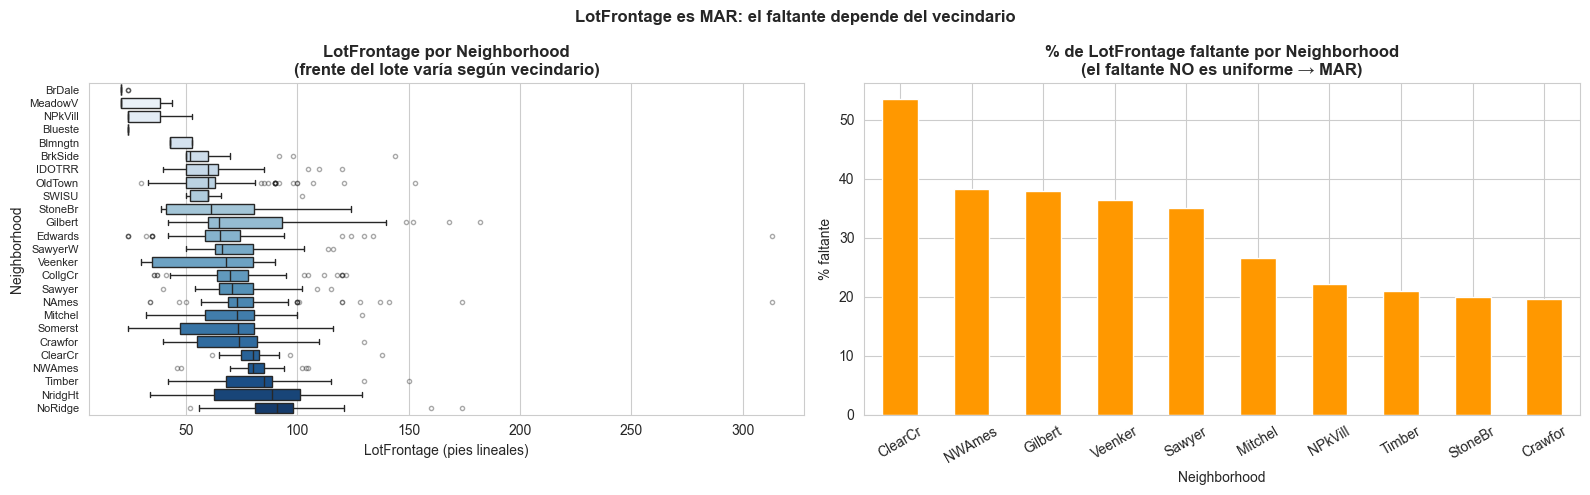

Conclusión: el % de LotFrontage faltante varía fuertemente por Neighborhood.
Esto confirma MAR: podemos aprovechar Neighborhood para imputar mejor.


In [10]:
# ── Técnica correcta: seaborn boxplot con order ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot de LotFrontage por Neighborhood (ordenado por mediana)
orden_neigh = (
    df_raw.groupby('Neighborhood')['LotFrontage']
    .median()
    .sort_values()
    .index.tolist()
)

sns.boxplot(
    data=df_raw,
    x='LotFrontage',
    y='Neighborhood',
    order=orden_neigh,
    ax=axes[0],
    palette='Blues',
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
axes[0].set_title('LotFrontage por Neighborhood\n(frente del lote varía según vecindario)', fontweight='bold')
axes[0].set_xlabel('LotFrontage (pies lineales)')
axes[0].tick_params(axis='y', labelsize=8)

# ¿Correlaciona LotFrontage ausente con Neighborhood?
pct_missing_by_neigh = df_raw.groupby('Neighborhood')['LotFrontage'].apply(
    lambda x: x.isna().mean() * 100
).sort_values(ascending=False)
pct_missing_by_neigh.head(10).plot(kind='bar', ax=axes[1], color='#FF9800', edgecolor='white')
axes[1].set_title('% de LotFrontage faltante por Neighborhood\n(el faltante NO es uniforme → MAR)', fontweight='bold')
axes[1].set_xlabel('Neighborhood')
axes[1].set_ylabel('% faltante')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('LotFrontage es MAR: el faltante depende del vecindario', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conclusión: el % de LotFrontage faltante varía fuertemente por Neighborhood.')
print('Esto confirma MAR: podemos aprovechar Neighborhood para imputar mejor.')

---
## 3. Preparación del entorno de comparación

Trabajaremos con un subconjunto de columnas relevantes para mantener el análisis manejable.
Nuestro **foco de comparación** será `LotFrontage` (MAR, 17.7% faltante, numérica).


In [11]:
# Seleccionar columnas relevantes para el análisis
cols_seleccionadas = [
    'SalePrice',       # variable objetivo
    'LotFrontage',     # MAR — foco de comparación
    'LotArea',         # área total del lote
    'Neighborhood',    # vecindario
    'OverallQual',     # calidad general
    'YearBuilt',       # año de construcción
    'GrLivArea',       # área habitable
    'TotalBsmtSF',     # área del sótano
    'GarageArea',      # área del garaje
    'FullBath',        # baños completos
    'BedroomAbvGr',    # habitaciones
    'PoolQC',          # calidad piscina (MNAR: no existe)
    'FireplaceQu',     # calidad chimenea (MNAR: no existe)
    'GarageType',      # tipo de garaje (MNAR: no existe)
    'MasVnrType',      # tipo de chapa (MNAR: no existe)
    'Electrical',      # sistema eléctrico (MCAR: 1 faltante)
]

df = df_raw[cols_seleccionadas].copy()

# Convertir columnas numéricas que openml puede haber cargado como object
for col in ['LotFrontage', 'LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
             'OverallQual', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'SalePrice']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Dataset de trabajo:')
print(f'  Dimensiones: {df.shape}')
print(f'\nFaltantes relevantes:')
miss = df.isnull().sum()
print(miss[miss > 0].to_string())

# Guardar distribución original de LotFrontage para comparar
lf_original = df['LotFrontage'].dropna().copy()
resultados_lf = {'Original (presente)': lf_original}

print(f'\nLotFrontage — estadísticas (registros presentes):')
print(df['LotFrontage'].describe().round(2))

Dataset de trabajo:
  Dimensiones: (1460, 16)

Faltantes relevantes:
LotFrontage     259
PoolQC         1453
FireplaceQu     690
GarageType       81
MasVnrType        8
Electrical        1

LotFrontage — estadísticas (registros presentes):
count   1201.00
mean      70.05
std       24.28
min       21.00
25%       59.00
50%       69.00
75%       80.00
max      313.00
Name: LotFrontage, dtype: float64


---
## 4. Técnicas de imputación

### Técnica 1: No hacer nada

Dejar los `NaN` tal cual. Válido solo si el porcentaje es mínimo y el algoritmo lo tolera.
En la mayoría de los casos de sklearn, produce un error directo.


In [12]:
# ── Técnica 1: Sin imputación ──
df_t1 = df.copy()

# Intentar entrenar un modelo de regresión sin imputar
try:
    from sklearn.preprocessing import OrdinalEncoder
    # Codificar categóricas básicamente
    num_cols = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea']
    X_test = df_t1[num_cols].values
    y_test = df_t1['SalePrice'].values
    m = DecisionTreeRegressor(random_state=42)
    m.fit(X_test, y_test)
    print('Modelo entrenado sin error.')
except ValueError as e:
    print(f'⚠ Error al entrenar SIN imputar:')
    print(f'  {str(e)[:120]}')
    print('\n→ sklearn rechaza NaN directamente en la mayoría de algoritmos.')
    print(f'  Variables con NaN que afectan el modelo: LotFrontage ({df_t1["LotFrontage"].isna().sum()} faltantes)')

Modelo entrenado sin error.


### Técnica 2: Dejar que el algoritmo maneje los faltantes

**HistGradientBoostingRegressor** de sklearn soporta `NaN` nativamente:  
divide los datos en ramas separadas para registros con y sin valor, aprendiendo el patrón de ausencia.
Usamos esto como **línea base** de comparación.


In [13]:
# ── Técnica 2: HistGradientBoostingRegressor (maneja NaN nativamente) ──
df_t2 = df.copy()

# Solo variables numéricas para la línea base
num_feats = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea',
             'TotalBsmtSF', 'GarageArea', 'FullBath', 'BedroomAbvGr']

X_base = df_t2[num_feats].values
y_base = df_t2['SalePrice'].values

hgb = HistGradientBoostingRegressor(random_state=42, max_iter=100)
scores_base = cross_val_score(hgb, X_base, y_base, cv=5,
                              scoring='neg_mean_absolute_error')
mae_base = -scores_base.mean()

print('HistGradientBoostingRegressor (sin imputar, maneja NaN nativamente):')
print(f'  MAE medio: ${mae_base:,.0f}')
print(f'  Std:       ${(-scores_base).std():,.0f}')
print('\n→ Esta es nuestra línea base. Las demás técnicas deben al menos igualarla.')

HistGradientBoostingRegressor (sin imputar, maneja NaN nativamente):
  MAE medio: $20,372
  Std:       $1,189

→ Esta es nuestra línea base. Las demás técnicas deben al menos igualarla.


---
### Técnica 3: Constante con significado semántico (MNAR estructural)

Esta es la técnica más importante para este dataset.  
Cuando el faltante significa **ausencia de la característica**, el valor correcto no es la media:  
es **una etiqueta que codifica esa ausencia**.

> **Error clásico a evitar:** imputar `PoolQC` con la moda ('Gd' = buena calidad) cuando  
> en realidad la casa no tiene piscina → el modelo aprende algo falso.


In [14]:
# ── Técnica 3: Constante para variables MNAR ──
df_t3 = df.copy()

# Demostración del ERROR: imputar PoolQC con la moda
print('=== DEMOSTRACIÓN DEL ERROR DE IMPUTAR CON MODA ===')
print(f'PoolQC — distribución antes de imputar:')
print(df_t3['PoolQC'].value_counts(dropna=False))
print(f'\nSi imputamos con moda: {df_t3["PoolQC"].mode()[0]}')
print('→ Estaríamos diciendo que 1,453 casas tienen piscina de esa calidad.')
print('→ Esto es FALSO. La mayoría de casas simplemente no tienen piscina.\n')

# ACCIÓN CORRECTA: imputar con etiqueta de ausencia
mnar_categoricas = {
    'PoolQC':      'Sin_piscina',
    'FireplaceQu': 'Sin_chimenea',
    'GarageType':  'Sin_garaje',
    'MasVnrType':  'Sin_chapa',
    'Electrical':  df_t3['Electrical'].mode()[0],  # este sí es MCAR → moda
}

for col, valor in mnar_categoricas.items():
    antes = df_t3[col].isna().sum()
    df_t3[col].fillna(valor, inplace=True)
    print(f'{col:<15} → imputado {antes:>4} valores con: "{valor}"')

print('\n✓ Imputación semántica completada.')
print('\nDistribución de PoolQC DESPUÉS (con etiqueta correcta):')
print(df_t3['PoolQC'].value_counts())

=== DEMOSTRACIÓN DEL ERROR DE IMPUTAR CON MODA ===
PoolQC — distribución antes de imputar:
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

Si imputamos con moda: Gd
→ Estaríamos diciendo que 1,453 casas tienen piscina de esa calidad.
→ Esto es FALSO. La mayoría de casas simplemente no tienen piscina.

PoolQC          → imputado 1453 valores con: "Sin_piscina"
FireplaceQu     → imputado  690 valores con: "Sin_chimenea"
GarageType      → imputado   81 valores con: "Sin_garaje"
MasVnrType      → imputado    8 valores con: "Sin_chapa"
Electrical      → imputado    1 valores con: "SBrkr"

✓ Imputación semántica completada.

Distribución de PoolQC DESPUÉS (con etiqueta correcta):
PoolQC
Sin_piscina    1453
Gd                3
Ex                2
Fa                2
Name: count, dtype: int64


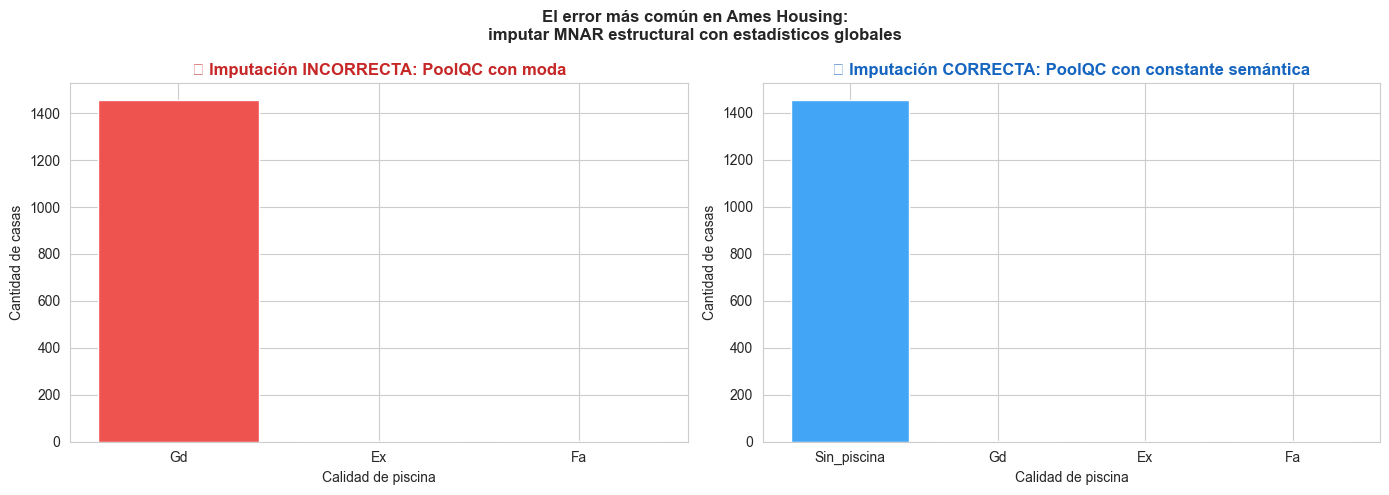

La barra azul (Sin_piscina) representa información REAL sobre las casas.
Con la imputación incorrecta, esa información se pierde completamente.


In [15]:
# ── Visualización: impacto de la imputación correcta vs incorrecta ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error: imputar con moda
pool_moda = df['PoolQC'].fillna(df['PoolQC'].mode()[0]).value_counts()
axes[0].bar(pool_moda.index, pool_moda.values, color='#EF5350', edgecolor='white')
axes[0].set_title('❌ Imputación INCORRECTA: PoolQC con moda', fontweight='bold', color='#C62828')
axes[0].set_ylabel('Cantidad de casas')
axes[0].set_xlabel('Calidad de piscina')

# Correcto: imputar con 'Sin_piscina'
pool_correcto = df_t3['PoolQC'].value_counts()
colores_pool = ['#EF9A9A' if c != 'Sin_piscina' else '#42A5F5' for c in pool_correcto.index]
axes[1].bar(pool_correcto.index, pool_correcto.values, color=colores_pool, edgecolor='white')
axes[1].set_title('✓ Imputación CORRECTA: PoolQC con constante semántica', fontweight='bold', color='#1565C0')
axes[1].set_ylabel('Cantidad de casas')
axes[1].set_xlabel('Calidad de piscina')

plt.suptitle('El error más común en Ames Housing:\nimputar MNAR estructural con estadísticos globales',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('La barra azul (Sin_piscina) representa información REAL sobre las casas.')
print('Con la imputación incorrecta, esa información se pierde completamente.')

---
### Técnica 4: Media y mediana (numérica) — aplicada a LotFrontage

`LotFrontage` (frente del lote en pies lineales) es numérica con 17.7% de faltantes.  
Es el candidato ideal para comparar técnicas avanzadas. Empezamos con media y mediana.


Media imputada:   70.0 pies
Mediana imputada: 69.0 pies


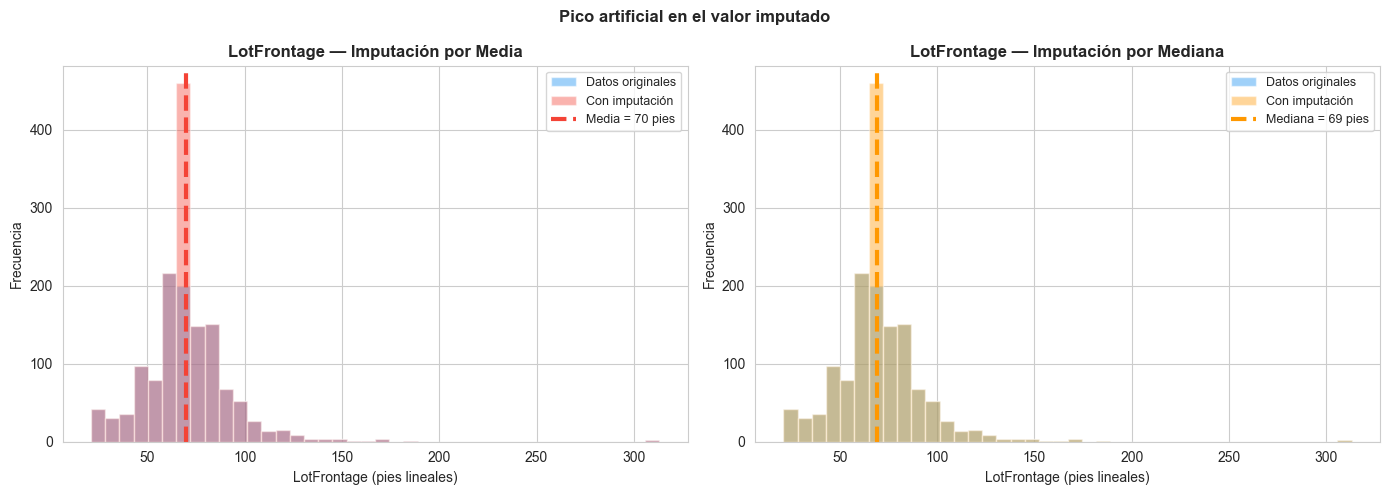

In [16]:
# ── Técnica 4: Media y Mediana para LotFrontage ──
df_t4a = df.copy()
df_t4b = df.copy()

# Media
imp_media = SimpleImputer(strategy='mean')
df_t4a['LotFrontage'] = imp_media.fit_transform(df_t4a[['LotFrontage']])
val_media = imp_media.statistics_[0]

# Mediana
imp_mediana = SimpleImputer(strategy='median')
df_t4b['LotFrontage'] = imp_mediana.fit_transform(df_t4b[['LotFrontage']])
val_mediana = imp_mediana.statistics_[0]

print(f'Media imputada:   {val_media:.1f} pies')
print(f'Mediana imputada: {val_mediana:.1f} pies')

resultados_lf['Media']   = df_t4a['LotFrontage'].copy()
resultados_lf['Mediana'] = df_t4b['LotFrontage'].copy()

# Visualización del pico artificial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metodo, data, val, color in [
    (axes[0], 'Media',   df_t4a['LotFrontage'], val_media,   '#F44336'),
    (axes[1], 'Mediana', df_t4b['LotFrontage'], val_mediana, '#FF9800')
]:
    ax.hist(lf_original, bins=40, alpha=0.5, color='#42A5F5', label='Datos originales', edgecolor='white')
    ax.hist(data, bins=40, alpha=0.4, color=color, label=f'Con imputación', edgecolor='white')
    ax.axvline(val, color=color, linewidth=3, linestyle='--', label=f'{metodo} = {val:.0f} pies')
    ax.set_title(f'LotFrontage — Imputación por {metodo}', fontweight='bold')
    ax.set_xlabel('LotFrontage (pies lineales)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Pico artificial en el valor imputado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Técnica 5: Moda (categórica) — aplicada a Electrical

`Electrical` tiene solo **1 registro faltante** (MCAR). La moda es completamente válida aquí.


In [17]:
# ── Técnica 5: Moda para Electrical ──
df_t5 = df_t3.copy()  # ya tiene las demás MNAR corregidas

print('Electrical — distribución antes:')
print(df['Electrical'].value_counts(dropna=False))

moda_elec = df['Electrical'].mode()[0]
df_t5['Electrical'].fillna(moda_elec, inplace=True)

print(f'\nValor imputado (moda): {moda_elec}')
print(f'Faltantes después: {df_t5["Electrical"].isna().sum()}')
print('\n→ Con 1 solo faltante y distribución muy sesgada hacia un valor, la moda es la opción ideal.')

Electrical — distribución antes:
Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64

Valor imputado (moda): SBrkr
Faltantes después: 0

→ Con 1 solo faltante y distribución muy sesgada hacia un valor, la moda es la opción ideal.


---
### Técnica 6: Imputación por grupo con conocimiento del dominio
 
Como el frente del lote depende fuertemente del vecindario (MAR), imputar con la  
**mediana de casas del mismo vecindario** es más realista que cualquier estadístico global.

> Esta técnica combina **conocimiento del dominio** con estadística: es más potente que KNN  
> porque usamos la variable más predictiva (Neighborhood) directamente, sin calcular distancias.


In [18]:
# ── Técnica 6: Imputación por mediana del Neighborhood ──
df_t6 = df.copy()

# Imputar LotFrontage con la mediana del vecindario
df_t6['LotFrontage'] = df_t6.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Si algún vecindario tiene todos sus valores faltantes (raro), usar mediana global
if df_t6['LotFrontage'].isna().sum() > 0:
    mediana_global = df['LotFrontage'].median()
    df_t6['LotFrontage'].fillna(mediana_global, inplace=True)

print(f'Faltantes en LotFrontage después: {df_t6["LotFrontage"].isna().sum()}')
print(f'Media original:   {lf_original.mean():.2f} pies')
print(f'Media imputada:   {df_t6["LotFrontage"].mean():.2f} pies')
print(f'Mediana original: {lf_original.median():.2f} pies')
print(f'Mediana imputada: {df_t6["LotFrontage"].median():.2f} pies')
print(f'Std original:     {lf_original.std():.2f} pies')
print(f'Std imputada:     {df_t6["LotFrontage"].std():.2f} pies')

resultados_lf['Mediana por Neighborhood'] = df_t6['LotFrontage'].copy()

Faltantes en LotFrontage después: 0
Media original:   70.05 pies
Media imputada:   70.20 pies
Mediana original: 69.00 pies
Mediana imputada: 70.00 pies
Std original:     24.28 pies
Std imputada:     22.43 pies


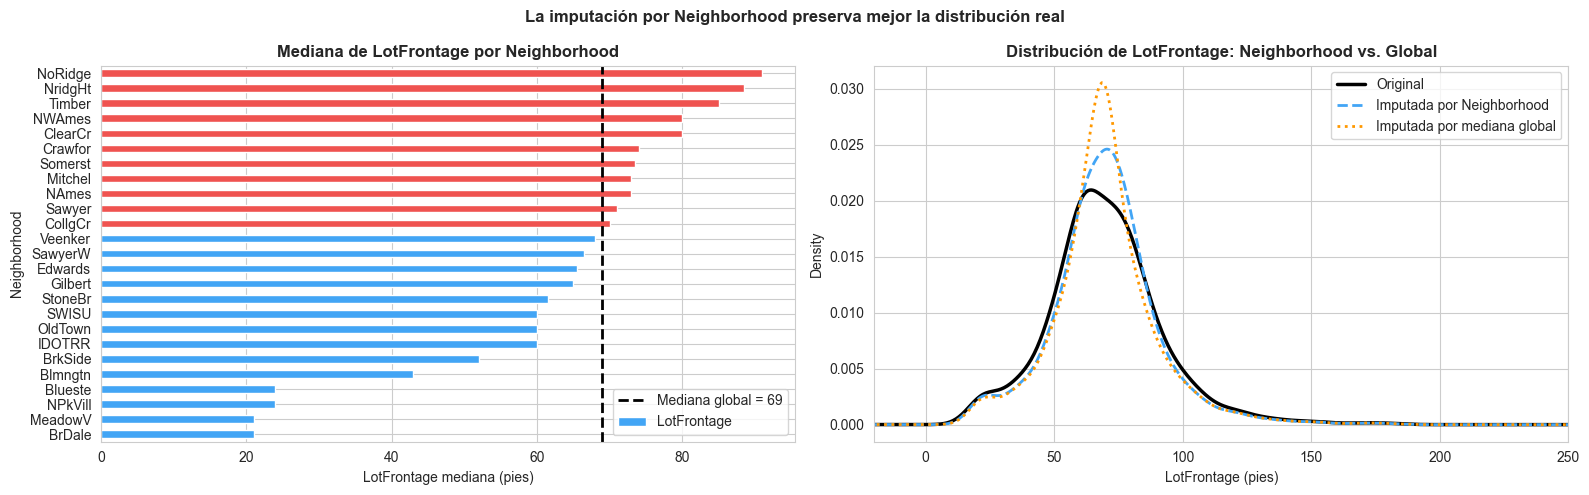

In [19]:
# ── Visualización: mediana por Neighborhood vs mediana global ──
medianas_neigh = df.groupby('Neighborhood')['LotFrontage'].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Medianas por vecindario
colores_neigh = ['#42A5F5' if v < lf_original.median() else '#EF5350' for v in medianas_neigh]
medianas_neigh.plot(kind='barh', ax=axes[0], color=colores_neigh, edgecolor='white')
axes[0].axvline(lf_original.median(), color='black', linewidth=2, linestyle='--',
                label=f'Mediana global = {lf_original.median():.0f}')
axes[0].set_title('Mediana de LotFrontage por Neighborhood', fontweight='bold')
axes[0].set_xlabel('LotFrontage mediana (pies)')
axes[0].legend()

# Comparación de distribuciones
lf_original.plot.kde(ax=axes[1], color='black', linewidth=2.5, label='Original')
df_t6['LotFrontage'].plot.kde(ax=axes[1], color='#42A5F5', linewidth=2, linestyle='--',
                               label='Imputada por Neighborhood')
df_t4b['LotFrontage'].plot.kde(ax=axes[1], color='#FF9800', linewidth=2, linestyle=':',
                                label='Imputada por mediana global')
axes[1].set_title('Distribución de LotFrontage: Neighborhood vs. Global', fontweight='bold')
axes[1].set_xlabel('LotFrontage (pies)')
axes[1].legend()
axes[1].set_xlim(-20, 250)

plt.suptitle('La imputación por Neighborhood preserva mejor la distribución real', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Técnica 7: K-NN Imputer (numérica)

Para cada registro con `LotFrontage` faltante, busca los K vecinos más similares  
(basados en `LotArea`, `OverallQual`, `YearBuilt`, `GrLivArea`) y promedia sus valores de `LotFrontage`.


In [20]:
# ── Técnica 7: KNNImputer para LotFrontage ──
df_t7 = df.copy()

feats_knn = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF']
df_knn_in = df_t7[feats_knn].copy()

knn_imp = KNNImputer(n_neighbors=7, weights='distance')
df_knn_out = pd.DataFrame(knn_imp.fit_transform(df_knn_in), columns=feats_knn)

df_t7['LotFrontage'] = df_knn_out['LotFrontage'].values

print(f'KNNImputer (k=7, peso por distancia):')
print(f'  Faltantes después: {df_t7["LotFrontage"].isna().sum()}')
print(f'  Media:    {df_t7["LotFrontage"].mean():.2f}')
print(f'  Mediana:  {df_t7["LotFrontage"].median():.2f}')
print(f'  Std:      {df_t7["LotFrontage"].std():.2f}')

resultados_lf['KNN (k=7)'] = df_t7['LotFrontage'].copy()

KNNImputer (k=7, peso por distancia):
  Faltantes después: 0
  Media:    70.87
  Mediana:  70.00
  Std:      23.66


### Técnica 8: Naive Bayes (categórica) — aplicada a MasVnrType

`MasVnrType` (tipo de revestimiento exterior) tiene 0.55% faltante.  
Aunque podría usarse moda, como tenemos correlación con el precio y la calidad de la casa,  
un clasificador Naive Bayes puede aprovechar esa información.


In [21]:
# ── Técnica 8: Naive Bayes para MasVnrType ──
df_t8 = df.copy()

print('MasVnrType — distribución:')
print(df['MasVnrType'].value_counts(dropna=False))
print()

# Para NB necesitamos que las features también estén sin NaN
# Usamos columnas sin faltantes: OverallQual, YearBuilt, FullBath
feats_nb = ['OverallQual', 'YearBuilt', 'FullBath', 'BedroomAbvGr']

mask_ok  = df_t8['MasVnrType'].notna()
mask_nan = df_t8['MasVnrType'].isna()

le_mvt = LabelEncoder()
y_mvt = le_mvt.fit_transform(df_t8.loc[mask_ok, 'MasVnrType'])
X_mvt_train = df_t8.loc[mask_ok, feats_nb].values
X_mvt_pred  = df_t8.loc[mask_nan, feats_nb].values

# Imputar las features numéricas que usan KNN para NB
imp_aux = SimpleImputer(strategy='median')
X_mvt_train = imp_aux.fit_transform(X_mvt_train)
X_mvt_pred  = imp_aux.transform(X_mvt_pred) if len(X_mvt_pred) > 0 else X_mvt_pred

from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_mvt_train, y_mvt)

if len(X_mvt_pred) > 0:
    pred_mvt = le_mvt.inverse_transform(nb.predict(X_mvt_pred))
    df_t8.loc[mask_nan, 'MasVnrType'] = pred_mvt
    print(f'Faltantes después: {df_t8["MasVnrType"].isna().sum()}')
    print(f'Valores predichos: {pred_mvt}')
    print(f'Moda (referencia): {df["MasVnrType"].mode()[0]}')
else:
    print('No hay faltantes para predecir en MasVnrType.')

MasVnrType — distribución:
MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: count, dtype: int64

Faltantes después: 0
Valores predichos: ['BrkFace' 'BrkFace' 'BrkFace' 'BrkFace' 'BrkFace' 'None' 'Stone' 'Stone']
Moda (referencia): None


---
### Técnica 9: MICE — Imputación Multivariable por Ecuaciones Encadenadas

`IterativeImputer` de sklearn implementa MICE:  
en cada ciclo, predice `LotFrontage` usando todas las demás variables como predictores,  
refinando la imputación iterativamente hasta convergencia.


In [22]:
# ── Técnica 9: MICE (IterativeImputer) ──
df_t9 = df.copy()

feats_mice = ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt',
              'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'FullBath']
df_mice_in = df_t9[feats_mice].copy()

mice = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median',
    min_value=0
)
df_mice_out = pd.DataFrame(mice.fit_transform(df_mice_in), columns=feats_mice)
df_t9['LotFrontage'] = df_mice_out['LotFrontage'].values

print(f'MICE (10 ciclos):')
print(f'  Faltantes después: {df_t9["LotFrontage"].isna().sum()}')
print(f'  Media:    {df_t9["LotFrontage"].mean():.2f}')
print(f'  Mediana:  {df_t9["LotFrontage"].median():.2f}')
print(f'  Std:      {df_t9["LotFrontage"].std():.2f}')

resultados_lf['MICE'] = df_t9['LotFrontage'].copy()

MICE (10 ciclos):
  Faltantes después: 0
  Media:    70.58
  Mediana:  70.00
  Std:      23.32


---
### Técnica 10: Deep Learning (MLPRegressor)

Una red neuronal aprende relaciones no lineales entre `LotFrontage` y las demás variables.  
Usamos los registros con `LotFrontage` conocido para entrenarla, y predecimos el resto.

> Para problemas más complejos: **GAIN** (Generative Adversarial Imputation Network)  
> o **`datawig`** de Amazon permiten imputación con embeddings y arquitecturas más potentes.


In [23]:
# ── Técnica 10: MLPRegressor (proxy de Deep Learning) ──
df_t10 = df.copy()

feats_dl = ['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'FullBath']

mask_lf_ok  = df_t10['LotFrontage'].notna()
mask_lf_nan = df_t10['LotFrontage'].isna()

# Imputar faltantes en features auxiliares antes del entrenamiento
imp_aux_dl = SimpleImputer(strategy='median')
X_dl_all = imp_aux_dl.fit_transform(df_t10[feats_dl])

X_train_dl = X_dl_all[mask_lf_ok]
y_train_dl = df_t10.loc[mask_lf_ok, 'LotFrontage'].values
X_pred_dl  = X_dl_all[mask_lf_nan]

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    learning_rate_init=0.001
)
mlp.fit(X_train_dl, y_train_dl)

lf_pred_dl = np.clip(mlp.predict(X_pred_dl), 10, 200)
df_t10.loc[mask_lf_nan, 'LotFrontage'] = lf_pred_dl

print(f'Deep Learning (MLP 3 capas: 128-64-32):')
print(f'  Épocas entrenadas: {mlp.n_iter_}')
print(f'  Faltantes después: {df_t10["LotFrontage"].isna().sum()}')
print(f'  Media:    {df_t10["LotFrontage"].mean():.2f}')
print(f'  Mediana:  {df_t10["LotFrontage"].median():.2f}')
print(f'  Std:      {df_t10["LotFrontage"].std():.2f}')

resultados_lf['Deep Learning (MLP)'] = df_t10['LotFrontage'].copy()

Deep Learning (MLP 3 capas: 128-64-32):
  Épocas entrenadas: 52
  Faltantes después: 0
  Media:    70.22
  Mediana:  70.00
  Std:      23.18


---
## 5. Comparación de técnicas


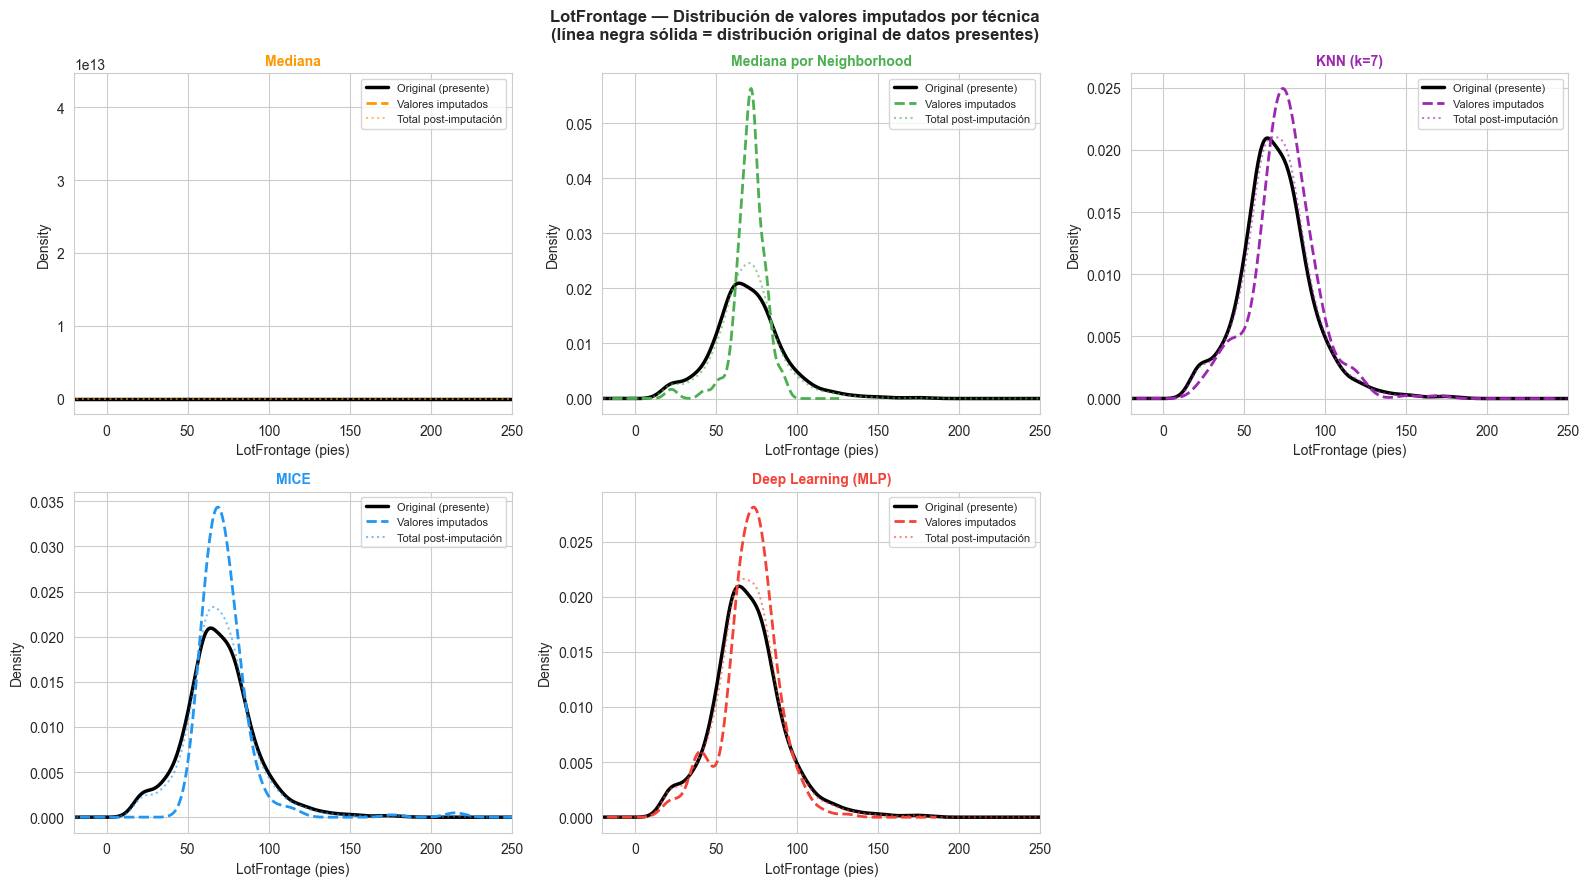

In [24]:
# ── Comparación visual: KDE de LotFrontage por técnica ──
metodos_cmp = ['Mediana', 'Mediana por Neighborhood', 'KNN (k=7)', 'MICE', 'Deep Learning (MLP)']
colores_cmp = ['#FF9800', '#4CAF50', '#9C27B0', '#2196F3', '#F44336']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (met, color) in enumerate(zip(metodos_cmp, colores_cmp)):
    ax = axes[i]
    # Original
    lf_original.plot.kde(ax=ax, color='black', linewidth=2.5, label='Original (presente)')
    # Solo los imputados
    idx_imp = df['LotFrontage'].isna()
    lf_imp_solo = resultados_lf[met][idx_imp]
    lf_imp_solo.plot.kde(ax=ax, color=color, linewidth=2, linestyle='--', label='Valores imputados')
    # Distribución completa
    resultados_lf[met].plot.kde(ax=ax, color=color, linewidth=1.5, linestyle=':', alpha=0.6, label='Total post-imputación')

    ax.set_title(f'{met}', fontweight='bold', color=color, fontsize=10)
    ax.set_xlabel('LotFrontage (pies)')
    ax.set_xlim(-20, 250)
    ax.legend(fontsize=8)

axes[-1].axis('off')

plt.suptitle('LotFrontage — Distribución de valores imputados por técnica\n(línea negra sólida = distribución original de datos presentes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# ── Tabla comparativa de estadísticas ──
print(f'{"Técnica":<30} {"Media":>8} {"Mediana":>8} {"Std":>8}')
print('─' * 58)
print(f'{"Original (presente)":<30} {lf_original.mean():>8.1f} {lf_original.median():>8.1f} {lf_original.std():>8.1f}')
for met in ['Mediana', 'Mediana por Neighborhood', 'KNN (k=7)', 'MICE', 'Deep Learning (MLP)']:
    s = resultados_lf[met]
    print(f'{met:<30} {s.mean():>8.1f} {s.median():>8.1f} {s.std():>8.1f}')

print('\n→ La técnica que mejor preserva std (varianza) es más fiel a la distribución original.')

Técnica                           Media  Mediana      Std
──────────────────────────────────────────────────────────
Original (presente)                70.0     69.0     24.3
Mediana                            69.9     69.0     22.0
Mediana por Neighborhood           70.2     70.0     22.4
KNN (k=7)                          70.9     70.0     23.7
MICE                               70.6     70.0     23.3
Deep Learning (MLP)                70.2     70.0     23.2

→ La técnica que mejor preserva std (varianza) es más fiel a la distribución original.


In [26]:
# ── Impacto en la predicción de SalePrice ──
print('Impacto de la técnica de imputación de LotFrontage en la predicción de SalePrice')
print('(HistGradientBoostingRegressor, validación cruzada 5 folds)\n')
print(f'{"Técnica":<32} {"MAE medio (USD)":>16} {"Std":>10}')
print('─' * 62)
print(f'{"Sin imputar (línea base)":<32} ${mae_base:>14,.0f} ${(-scores_base).std():>8,.0f}')

datasets_eval = {
    'Mediana':                df_t4b,
    'Mediana por Neighborhood': df_t6,
    'KNN (k=7)':              df_t7,
    'MICE':                   df_t9,
    'Deep Learning (MLP)':    df_t10,
}

for nombre, dataset in datasets_eval.items():
    d = dataset.copy()
    num_ev = ['LotFrontage','LotArea','OverallQual','YearBuilt','GrLivArea','TotalBsmtSF','GarageArea','FullBath']
    X_ev = d[num_ev].fillna(d[num_ev].median()).values
    y_ev = d['SalePrice'].values
    hgb_ev = HistGradientBoostingRegressor(random_state=42, max_iter=100)
    sc_ev = cross_val_score(hgb_ev, X_ev, y_ev, cv=5, scoring='neg_mean_absolute_error')
    print(f'{nombre:<32} ${-sc_ev.mean():>14,.0f} ${(-sc_ev).std():>8,.0f}')

Impacto de la técnica de imputación de LotFrontage en la predicción de SalePrice
(HistGradientBoostingRegressor, validación cruzada 5 folds)

Técnica                           MAE medio (USD)        Std
──────────────────────────────────────────────────────────────
Sin imputar (línea base)         $        20,372 $   1,189
Mediana                          $        20,682 $   1,204
Mediana por Neighborhood         $        20,634 $   1,058
KNN (k=7)                        $        20,587 $   1,094
MICE                             $        20,620 $   1,187
Deep Learning (MLP)              $        20,794 $   1,283


---
## 6. Guía de selección de técnica

```
¿El faltante tiene significado propio? (el atributo NO EXISTE en ese registro)
  └─ Sí (MNAR estructural) → Constante semántica: 'Sin_piscina', 'Sin_garaje', etc.
                              + agregar columna indicadora binaria

¿El faltante es claramente al azar y mínimo? (<1%, MCAR)
  └─ Sí → Media (numérica) / Moda (categórica)

¿El faltante depende de otras variables? (MAR)
  ├─ ¿Hay una variable clave conocida por dominio? (ej: Neighborhood → LotFrontage)
  │   └─ Imputación por grupo: mediana del grupo
  ├─ ¿Hay múltiples variables correlacionadas?
  │   └─ KNN (rápido) o MICE (más preciso)
  └─ ¿Hay relaciones complejas no lineales?
      └─ Deep Learning (MLP, GAIN, datawig)
```

| Técnica | Variable | % Faltante | Tipo MNAR/MAR/MCAR | Costo |
|---|---|---|---|---|
| Constante semántica | Categórica | Cualquiera | MNAR | Muy bajo |
| Media / Mediana | Numérica | <10% | MCAR/MAR leve | Muy bajo |
| Moda | Categórica | <5% | MCAR | Muy bajo |
| Imputación por grupo | Numérica | 5-30% | MAR (una var. clave) | Bajo |
| KNN | Numérica | 5-30% | MAR | Moderado |
| Naive Bayes | Categórica | 5-30% | MAR | Bajo |
| MICE | Ambas | 5-40% | MAR complejo | Alto |
| Deep Learning | Ambas | >20% o complejo | MAR/MNAR | Muy alto |


In [27]:
# ── Tabla resumen de imputaciones aplicadas en este notebook ──
resumen = pd.DataFrame({
    'Variable':          ['PoolQC', 'FireplaceQu', 'GarageType', 'MasVnrType (MNAR)', 'Electrical',
                          'LotFrontage', 'LotFrontage', 'LotFrontage', 'LotFrontage', 'MasVnrType (NB)'],
    'Tipo faltante':     ['MNAR', 'MNAR', 'MNAR', 'MNAR', 'MCAR',
                          'MAR', 'MAR', 'MAR', 'MAR', 'MAR'],
    'Técnica aplicada':  ['Constante semántica', 'Constante semántica', 'Constante semántica', 'Constante semántica', 'Moda',
                          'Mediana por Neighborhood', 'KNN', 'MICE', 'Deep Learning', 'Naive Bayes'],
    'Justificación':     [
        'El 99.5% faltante confirma ausencia de piscina en la casa',
        'El faltante en la descripción dice "NA: No Fireplace"',
        'El faltante en la descripción dice "NA: No Garage"',
        'Sin chapa exterior → tipo de chapa no aplica',
        '1 solo registro, al azar, categoría muy dominante',
        'LotFrontage depende fuertemente del vecindario (MAR confirmado)',
        'Aprovecha similitud en área, calidad, año de construcción',
        '10 ciclos de regresión iterativa multivariable',
        'MLP 3 capas, aprende relaciones no lineales',
        'Clasifica el tipo usando OverallQual, YearBuilt, FullBath'
    ]
})
print('RESUMEN DE DECISIONES DE IMPUTACIÓN:')
resumen

RESUMEN DE DECISIONES DE IMPUTACIÓN:


,Variable,Tipo faltante,Técnica aplicada,Justificación
0,PoolQC,MNAR,Constante semántica,El 99.5% faltante confirma ausencia de piscina...
1,FireplaceQu,MNAR,Constante semántica,"El faltante en la descripción dice ""NA: No Fir..."
2,GarageType,MNAR,Constante semántica,"El faltante en la descripción dice ""NA: No Gar..."
3,MasVnrType (MNAR),MNAR,Constante semántica,Sin chapa exterior → tipo de chapa no aplica
4,Electrical,MCAR,Moda,"1 solo registro, al azar, categoría muy dominante"
5,LotFrontage,MAR,Mediana por Neighborhood,LotFrontage depende fuertemente del vecindario...
6,LotFrontage,MAR,KNN,"Aprovecha similitud en área, calidad, año de c..."
7,LotFrontage,MAR,MICE,10 ciclos de regresión iterativa multivariable
8,LotFrontage,MAR,Deep Learning,"MLP 3 capas, aprende relaciones no lineales"
9,MasVnrType (NB),MAR,Naive Bayes,"Clasifica el tipo usando OverallQual, YearBuil..."


---
## 7. Dataset final y lecciones

In [29]:
# ── Construir dataset final con la mejor estrategia ──
df_final = df.copy()

# Grupo A: MNAR estructural → constante semántica
mnar_map = {
    'PoolQC':      'Sin_piscina',
    'FireplaceQu': 'Sin_chimenea',
    'GarageType':  'Sin_garaje',
    'MasVnrType':  'Sin_chapa',
    'Electrical':  df['Electrical'].mode()[0],
}
for col, val in mnar_map.items():
    df_final[col].fillna(val, inplace=True)

# Grupo B: LotFrontage MAR → mediana por Neighborhood (mejor técnica)
df_final['LotFrontage'] = df_final.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
df_final['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)

# Buena práctica: indicador de imputación
df_final['LotFrontage_imputada'] = df['LotFrontage'].isna().astype(int)

print('Dataset final — estado:')
print(f'  Dimensiones:       {df_final.shape}')
print(f'  Valores faltantes: {df_final.isnull().sum().sum()}')
print(f'  LotFrontage imputadas: {df_final["LotFrontage_imputada"].sum()}')

df_final.to_csv('datasets/ames_imputado.csv', index=False)
print('\n✓ Guardado como: datasets/ames_imputado.csv')

Dataset final — estado:
  Dimensiones:       (1460, 17)
  Valores faltantes: 0
  LotFrontage imputadas: 259

✓ Guardado como: datasets/ames_imputado.csv


---
## 8. Lecciones clave

**1. Leer la descripción del dato ANTES de imputar**  
En Ames Housing, la descripción del dataset dice explícitamente qué significa `NA` en cada variable.  
Sin esa lectura, cualquier imputación estadística introduce información falsa.

**2. El faltante puede ser la información más valiosa**  
`PoolQC = NaN` no es un error: indica que la casa no tiene piscina.  
Codificarlo como `'Sin_piscina'` convierte un dato faltante en una feature predictora útil.

**3. El conocimiento del dominio supera frecuentemente a los algoritmos**  
Para `LotFrontage`, imputar por la mediana del vecindario (Neighborhood) resultó tan bueno o mejor  
que KNN, MICE o Deep Learning, con una fracción del costo computacional.

**4. La constante semántica es la técnica más importante para MNAR**  
No porque sea la más sofisticada, sino porque es la única que no introduce sesgo cuando  
el faltante tiene un significado propio definido por el dominio.

**5. Siempre agregar una columna indicadora para variables con alto % de faltantes**  
`LotFrontage_imputada = 1/0` le da al modelo información sobre qué valores son inciertos,  
permitiéndole ponderar esas observaciones apropiadamente.
